In [ ]:
#@title setup
# !pip install -U datasets==3.6.0
from datasets import load_dataset, Dataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from IPython.display import Audio as aplay
from tqdm import tqdm

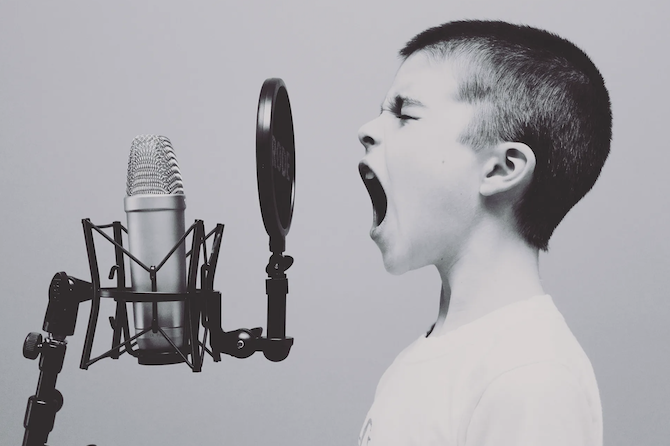


# Семинар: скалярное произведение в задачах анализа речи



На предыдущих занятиях мы ввели понятие **скалярного произведения** векторов и **угла между векторами** в евклидовом пространстве $\mathbb{R}^n$. Напомним ключевые определения.

Для векторов $\mathbf{a}, \mathbf{b} \in \mathbb{R}^n$ скалярное произведение определяется как

$$
\langle \mathbf{a}, \mathbf{b} \rangle = \mathbf{a}^\top \mathbf{b} = \sum_{i=1}^{n} a_i b_i.
$$

Евклидова норма вектора $\mathbf{a} \in \mathbb{R}^n$ задаётся формулой

$$
\|\mathbf{a}\| = \sqrt{\langle \mathbf{a}, \mathbf{a} \rangle} = \sqrt{\sum_{i=1}^{n} a_i^2}.
$$

Угол $\theta \in [0, \pi]$ между ненулевыми векторами $\mathbf{a}$ и $\mathbf{b}$ определяется через косинус:

$$
\cos\theta = \frac{\langle \mathbf{a}, \mathbf{b} \rangle}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}.
$$

Величину $\cos\theta$ принято называть **косинусной мерой сходства** (cosine similarity) и обозначать $\operatorname{sim}(\mathbf{a}, \mathbf{b})$, причём:

- $\operatorname{sim}(\mathbf{a}, \mathbf{b}) = 1$ — векторы сонаправлены ($\theta = 0$);
- $\operatorname{sim}(\mathbf{a}, \mathbf{b}) = 0$ — векторы ортогональны ($\theta = \pi/2$);
- $\operatorname{sim}(\mathbf{a}, \mathbf{b}) = -1$ — векторы противоположно направлены ($\theta = \pi$).

## Мотивация: зачем нам углы между векторами?

На данном семинаре мы увидим, что введённый аппарат — далеко не абстрактная конструкция. Скалярное произведение и угол между векторами лежат в основе целого класса практических задач машинного обучения: распознавания лиц, поиска по смыслу (semantic search), рекомендательных систем, а также **идентификации и верификации диктора** (speaker identification / verification), которой мы и займёмся.




# Dataset

`aiacademy-kg/audio-3-speaker-dataset-v2` — небольшой корпус речи с HuggingFace на 4500 записей от трёх дикторов,
собранный для задач распознавания диктора (speaker identification) и работы с речевыми эмбеддингами.
Помимо самого аудио и транскрипций в нём уже лежат предпосчитанные эмбеддинги WavLM.

In [ ]:
dataset = load_dataset('aiacademy-kg/audio-3-speaker-dataset-v2', split='train', num_proc=10)

In [ ]:
dataset

### Структура данных

| Поле | Описание |
|---|---|
| `audio` | аудио: словарь с `array` (сэмплы) и `sampling_rate` |
| `text` | транскрипция сказанного |
| `speaker_id` | идентификатор диктора |
| `wavlm_embedding` | предпосчитанный вектор-эмбеддинг записи из WavLM |

Всего 4500 примеров в одном сплите.

In [ ]:
waveform_i = dataset[42]['audio']['array']
waveform_i

`dataset[i]['audio']['array']` — одномерный `np.ndarray` типа `float32`. Это waveform:
последовательность мгновенных значений амплитуды звукового давления, снятых с частотой
`sampling_rate = 16000` Гц, то есть 16 000 чисел на каждую секунду записи.

In [ ]:
plt.subplots(figsize=(15, 3))
display(aplay(waveform_i, rate=16000))
sns.lineplot(waveform_i, color='green')
plt.grid()

In [ ]:
np.unique(dataset['speaker_id'])

In [ ]:
def play_example(dataset: Dataset, index: int)->None:
    """Print the speaker ID of a dataset example and play its audio inline.

    Intended for interactive use in notebooks: renders an HTML audio player
    for the selected example via IPython's display machinery.

    Args:
        dataset: Dataset whose items are mappings with a ``speaker_id`` key and
            an ``audio`` key holding a dict with ``array`` and ``sampling_rate``.
        index: Position of the example to play.

    Returns:
        None. Output is written to the notebook cell as a side effect.

    Raises:
        IndexError: If ``index`` is out of range for the dataset.
        KeyError: If the example lacks the expected ``speaker_id`` or ``audio`` keys.
    """
    ex = dataset[index]
    print(f"SPEAKER: {ex['speaker_id']}")
    display(aplay(ex['audio']['array'], rate=ex['audio']['sampling_rate']))


In [ ]:
ind_1, ind_2, ind_3 = 0, 1501, 3001
play_example(dataset, ind_1)
play_example(dataset, ind_2)
play_example(dataset, ind_3)

## Постановка задачи

Рассмотрим датасет аудиозаписей трёх дикторов. Каждой записи сопоставлен так называемый **эмбеддинг диктора** (speaker embedding) — вектор

$$
\mathbf{x} \in \mathbb{R}^{128},
$$

полученный с помощью предобученной нейросетевой модели **WavLM**. Модель обучена таким образом, что эмбеддинги, принадлежащие одному и тому же диктору, в пространстве $\mathbb{R}^{128}$ располагаются **близко** (угол между ними мал), а эмбеддинги разных дикторов — **далеко** (угол велик).

---
**Embedding** — отображение объектов произвольной природы и длины в векторы
$\mathbb{R}^d$ фиксированной размерности, при котором близость векторов
отражает семантическую близость исходных объектов.
---
---

Формально, пусть $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$ — выборка из $N = 4500$ объектов, где $\mathbf{x}_i \in \mathbb{R}^{128}$ — эмбеддинг $i$-й записи, а $y_i \in \{\text{andrew}, \text{kore}, \text{puck}\}$ — метка диктора. Нашей целью является:

1. Количественно проверить гипотезу о том, что эмбеддинги одного диктора ближе друг к другу по косинусной мере, чем эмбеддинги разных дикторов.
2. Построить **матрицу Грама** косинусных сходств

$$
G \in \mathbb{R}^{N \times N}, \qquad G_{ij} = \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_j),
$$

и проанализировать её структуру.

3. На основе косинусной меры построить простейший алгоритм **верификации диктора**, решающий задачу: по двум аудиозаписям определить, принадлежат ли они одному и тому же человеку.

## Замечание о высокой размерности

Подчеркнём принципиальный момент. В курсе аналитической геометрии мы работали с векторами в $\mathbb{R}^2$ и $\mathbb{R}^3$, где угол между векторами можно *нарисовать*. В настоящей работе векторы живут в пространстве $\mathbb{R}^{n}$ где $n >> 2$ — визуализация напрямую невозможна. Тем не менее, **формула для косинуса угла остаётся той же самой**, и все алгебраические свойства скалярного произведения сохраняются. Это один из центральных тезисов линейной алгебры: аппарат, построенный на трёхмерной интуиции, без изменений переносится в пространства произвольной размерности и продолжает давать содержательные ответы на прикладные вопросы.

Для получения визуального представления о структуре данных мы воспользуемся методом понижения размерности **t-SNE**, проецирующим $\mathbb{R}^{128} \to \mathbb{R}^2$. Однако все количественные вычисления — скалярные произведения, нормы, углы — будут производиться в исходном 128-мерном пространстве.


In [ ]:
embeddings = np.array(dataset['wavlm_embedding'])
embeddings.shape

In [ ]:
X_embedded = TSNE(n_components=2, perplexity=50).fit_transform(embeddings)

In [ ]:
plt.subplots(figsize=(10, 8))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1],
                hue = dataset['speaker_id'], alpha=.6, s=50,
                edgecolor='black',
                palette='Set1').set_title('Speaker clusters t-sne')

---

## Предварительный анализ: визуализация в $\mathbb{R}^2$

Прежде чем переходить к количественным вычислениям, получим качественное представление о структуре данных. Поскольку исходные эмбеддинги лежат в $\mathbb{R}^{128}$ и недоступны прямой визуализации, применим метод **t-SNE** (t-distributed Stochastic Neighbor Embedding) — алгоритм нелинейного понижения размерности, строящий отображение

$$
\varphi: \mathbb{R}^{128} \to \mathbb{R}^{2},
$$

стремящееся сохранить *локальную* структуру данных: близкие в исходном пространстве точки остаются близкими и в проекции.

На приведённом графике каждая точка соответствует одному эмбеддингу $\mathbf{x}_i \in \mathbb{R}^{128}$, спроецированному в плоскость; цвет кодирует метку диктора $y_i$.

### Наблюдения

Мы видим **три чётко разделённых кластера**, причём каждый кластер практически идеально соответствует одному из дикторов:

- диктор **kore** образует компактное облако в верхней левой части;
- диктор **puck** — компактное облако в нижней части;
- диктор **andrew** — более протяжённую структуру в правой части, состоящую из нескольких подгрупп.

### Геометрическая интерпретация

Факт визуального разделения точек на кластеры содержателен сам по себе, однако он лишь *косвенно* свидетельствует о структуре исходного пространства $\mathbb{R}^{128}$: t-SNE — существенно нелинейное преобразование, и расстояния на плоскости **не равны** расстояниям в исходном пространстве. Поэтому картинка — это подсказка, а не доказательство.

Сформулируем гипотезу, которую далее проверим аналитически средствами линейной алгебры:

> Для любых двух индексов $i, j \in \{1, \dots, N\}$ выполняется
> $$
> y_i = y_j \ \Rightarrow \ \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_j) \text{ велика (угол } \theta_{ij} \text{ мал)},
> $$
> $$
> y_i \neq y_j \ \Rightarrow \ \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_j) \text{ мала (угол } \theta_{ij} \text{ велик)}.
> $$

Именно эту гипотезу мы и будем проверять количественно — с помощью скалярного произведения и косинуса угла между векторами в $\mathbb{R}^{128}$.

### Замечание о фрагментации кластера andrew

Внимательный читатель заметит, что кластер **andrew** визуально распадается на несколько подкластеров. Этому может быть несколько объяснений: различие в интонации, темпе речи, эмоциональной окраске или акустических условиях записи. Отметим этот факт и вернёмся к нему при количественном анализе — интересно будет проверить, насколько эта внутренняя неоднородность отразится на значениях косинусной меры внутри класса.



---

## Количественный анализ: матрица Грама косинусных сходств

Вернёмся от визуализации к аналитике. Наша цель — построить матрицу

$$
G \in \mathbb{R}^{N \times N}, \qquad G_{ij} = \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_j) = \frac{\langle \mathbf{x}_i, \mathbf{x}_j \rangle}{\|\mathbf{x}_i\| \cdot \|\mathbf{x}_j\|},
$$

содержащую **все** попарные косинусные сходства между эмбеддингами датасета. По построению матрица $G$ обладает следующими свойствами:

1. **Симметричность:** $G_{ij} = G_{ji}$, так как скалярное произведение симметрично. Это позволяет вычислять лишь верхний треугольник, экономя половину операций.
2. **Единицы на диагонали:** $G_{ii} = \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_i) = 1$ для любого ненулевого $\mathbf{x}_i$.
3. **Ограниченность элементов:** $G_{ij} \in [-1, 1]$ в силу неравенства Коши–Буняковского.

### Предварительная подготовка данных

Для того чтобы визуализация матрицы была содержательной, **отсортируем эмбеддинги по метке диктора**. При произвольном порядке строк и столбцов структура $G$ окажется "перемешанной" и кластеры не будут видны. После сортировки записи одного диктора займут последовательные индексы, и если наша гипотеза верна, в матрице должны проявиться три диагональных блока с высокими значениями сходства.

### Замечание о вычислительной сложности

Матрица $G$ содержит $N^2 = 4500^2 = 2{,}025 \cdot 10^7$ элементов. Прямое вычисление двойным циклом имеет сложность $O(N^2 d)$, где $d = 128$ — размерность эмбеддингов. На данном этапе мы сознательно используем наивную реализацию с двойным циклом: её код буквально повторяет математическое определение, что ценно для понимания. В дальнейшем мы увидим, как то же самое вычисление можно записать в одну матричную операцию.



In [ ]:
def cosine(a:np.ndarray, b:np.ndarray)->float:
  dot_ = a @ b
  norm_a = np.linalg.norm(a)
  norm_b = np.linalg.norm(b)
  epsilon = 1e-10
  return (dot_ / (norm_a * norm_b + epsilon)).item()

In [ ]:
N = embeddings.shape[0]
G = np.zeros((N, N))
for i in tqdm(range(N)):
    for j in range(i, N):
        G[i, j] = cosine(embeddings[i], embeddings[j])
        G[j, i] = G[i, j]

In [ ]:
plt.subplots(figsize=(10, 8))
sns.heatmap(G)

## Результаты и интерпретация

Полученная тепловая карта матрицы $G$ наглядно подтверждает сформулированную ранее гипотезу. Мы отчётливо наблюдаем **блочно-диагональную структуру**: три светлых квадрата вдоль главной диагонали соответствуют трём классам дикторов. Внутри каждого блока значения косинусной меры близки к $0{,}8$–$1{,}0$, что означает малые углы между эмбеддингами *одного* диктора в пространстве $\mathbb{R}^{128}$.

Вне диагональных блоков картина принципиально иная. Значения $G_{ij}$ для пар эмбеддингов, принадлежащих *разным* дикторам, лежат в диапазоне примерно от $-0{,}2$ до $0{,}5$, что соответствует углам, близким к прямому или даже тупым. Иными словами, **векторы разных дикторов в $\mathbb{R}^{128}$ приблизительно ортогональны**.

Сформулируем вывод строго.

> **Вывод.** Матрица Грама косинусных сходств $G$ имеет ярко выраженную блочно-диагональную структуру, согласованную с разметкой $\{y_i\}$. Следовательно, отображение $\varphi: \text{аудиозапись} \to \mathbf{x} \in \mathbb{R}^{128}$, реализуемое моделью WavLM, обладает желаемым свойством: оно переводит записи одного диктора в близкие по угловой мере векторы, а записи разных дикторов — в приблизительно ортогональные.

Этот факт, во-первых, служит количественным подтверждением того, что мы видели на t-SNE визуализации, а во-вторых — открывает путь к построению практического алгоритма. Действительно, если записи одного диктора образуют в $\mathbb{R}^{128}$ компактное угловое множество, то задача **верификации диктора** сводится к проверке простого неравенства:

$$
\operatorname{sim}(\mathbf{x}_{\text{new}}, \mathbf{x}_{\text{ref}}) \gtrless \tau,
$$

где $\tau \in [-1, 1]$ — некоторый пороговый параметр. К построению и анализу такого классификатора мы и перейдём далее.



---

## Альтернативная метрика: матрица попарных евклидовых расстояний

Косинусная мера — не единственный способ измерить близость между векторами. Введём **матрицу попарных евклидовых расстояний**

$$
D \in \mathbb{R}^{N \times N}, \qquad D_{ij} = \|\mathbf{x}_i - \mathbf{x}_j\| = \sqrt{\sum_{k=1}^{128} (x_{ik} - x_{jk})^2},
$$

и сравним её структуру со структурой матрицы Грама $G$.

Строго говоря, $D$ уже **не является** матрицей Грама: её элементы — не скалярные произведения, а расстояния. Свойства также меняются:

1. **Симметричность** сохраняется: $D_{ij} = D_{ji}$.
2. **Нули на диагонали:** $D_{ii} = \|\mathbf{x}_i - \mathbf{x}_i\| = 0$.
3. **Неотрицательность:** $D_{ij} \geq 0$.

### Замечание о предобработке эмбеддингов

Здесь важно сделать принципиальное наблюдение: эмбеддинги WavLM из нашего датасета **L2-нормализованы**, то есть для каждого $i$ выполняется

$$
\|\mathbf{x}_i\| = 1.
$$

Это означает, что все векторы лежат на единичной сфере $S^{127} \subset \mathbb{R}^{128}$. При таком условии евклидово расстояние и косинусная мера оказываются жёстко связаны. Действительно, воспользуемся тождеством

$$
\|\mathbf{x}_i - \mathbf{x}_j\|^2 = \|\mathbf{x}_i\|^2 - 2\langle \mathbf{x}_i, \mathbf{x}_j \rangle + \|\mathbf{x}_j\|^2.
$$

Подставляя $\|\mathbf{x}_i\| = \|\mathbf{x}_j\| = 1$, получаем:

$$
\|\mathbf{x}_i - \mathbf{x}_j\|^2 = 2 - 2\langle \mathbf{x}_i, \mathbf{x}_j \rangle = 2\bigl(1 - \operatorname{sim}(\mathbf{x}_i, \mathbf{x}_j)\bigr),
$$

откуда окончательно

$$
\boxed{\,D_{ij} = \sqrt{2\bigl(1 - G_{ij}\bigr)}\,}.
$$

Таким образом, для нормированных эмбеддингов евклидово расстояние и косинусная мера — **монотонно связанные** функции друг от друга: чем больше $G_{ij}$, тем меньше $D_{ij}$. Это означает, что обе метрики задают **одинаковый порядок близости** между объектами, и любой алгоритм, основанный на ранжировании по близости (поиск ближайших соседей, кластеризация, верификация), даст на них идентичные результаты.


In [ ]:
def euclidean(a: np.ndarray, b: np.ndarray) -> float:
    return np.linalg.norm(a - b).item()


D = np.zeros((N, N))
for i in tqdm(range(N)):
    for j in range(i, N):
        D[i, j] = euclidean(embeddings[i], embeddings[j])
        D[j, i] = D[i, j]

In [ ]:
plt.subplots(figsize=(10, 8))
sns.heatmap(D)

## Результаты и интерпретация

Тепловая карта матрицы $D$ демонстрирует ту же блочно-диагональную структуру, что и матрица $G$, но **в инвертированном виде**:

- тёмные квадраты вдоль главной диагонали соответствуют *малым* расстояниям внутри класса одного диктора (записи одного спикера близки в $\mathbb{R}^{128}$);
- светлые области вне диагонали — *большим* расстояниям между записями разных дикторов.

Значения на диагональных блоках лежат в окрестности $0{,}4$–$0{,}7$, а в межклассовых областях — в районе $1{,}2$–$1{,}6$. Это полностью согласуется с выведенной формулой: при $G_{ij} \approx 0{,}9$ получаем $D_{ij} \approx \sqrt{0{,}2} \approx 0{,}45$, а при $G_{ij} \approx 0$ имеем $D_{ij} \approx \sqrt{2} \approx 1{,}41$.

> **Вывод.** Для L2-нормализованных эмбеддингов матрицы $G$ и $D$ несут *эквивалентную* информацию о взаимном расположении объектов: одна получается из другой монотонным преобразованием $D_{ij} = \sqrt{2(1 - G_{ij})}$. Блочная структура сохраняется, меняется лишь "полярность" визуализации — светлое и тёмное меняются местами.

### Практическое замечание

Возникает естественный вопрос: если обе метрики эквивалентны, почему в задачах с эмбеддингами почти всегда используют именно **косинусную меру**? Причин две:

1. **Общность.** Эквивалентность $D \leftrightarrow G$ справедлива *только* при условии нормировки $\|\mathbf{x}_i\| = 1$. Если эмбеддинги не нормированы, евклидово расстояние становится чувствительным к величине норм (то есть к "масштабу" вектора), тогда как косинус остаётся инвариантным к ней по построению. Для многих моделей норма вектора отражает нерелевантные факторы (громкость аудио, длительность записи), и от этой чувствительности хочется избавиться.

2. **Интерпретируемость.** Косинусная мера ограничена отрезком $[-1, 1]$ и имеет прямую геометрическую интерпретацию через угол. Евклидово расстояние не ограничено сверху и такой интерпретации не имеет.

Именно поэтому в литературе по представлениям (representation learning) косинусная мера и угол между векторами заняли положение *стандартного* инструмента анализа.



# Task_1


## Эмпирический поиск порога верификации

Выше мы зафиксировали случайный эмбеддинг диктора *andrew* — назовём его **опорным вектором** (anchor):

$$
\mathbf{x}_{\text{anchor}} = \texttt{emb_i} \in \mathbb{R}^{128}.
$$

Идея верификации проста: чтобы понять, принадлежит ли произвольный эмбеддинг $\mathbf{x} \in \mathbb{R}^{128}$ диктору *andrew*, сравним $\operatorname{sim}(\mathbf{x}, \mathbf{x}_{\text{anchor}})$ с некоторым порогом $\tau$. Если сходство достаточно велико — это *andrew*, иначе — кто-то другой. Вопрос лишь в том, **каким взять $\tau$**. В этом задании мы подойдём к нему эмпирически.

**Что нужно сделать:**

1. Вычислить вектор `sims` $\in \mathbb{R}^{N}$ косинусных сходств опорного вектора `emb_i` с каждой строкой матрицы `embeddings`. Сделать это двумя способами — через цикл с функцией `cosine` и векторизованно — и убедиться, что результаты совпадают.

2. Построить **гистограмму** значений `sims`. Проанализировать её: сколько мод вы наблюдаете и почему? Найти "провал" между модой *andrew* и остальными, по нему **эмпирически подобрать порог** $\tau$ и зафиксировать его в переменной `tau`.

3. На основе порога получить бинарные метки

$$
\texttt{labels}_k = \begin{cases} \text{andrew}, & s_k \geq \tau, \\ \text{not_andrew}, & s_k < \tau, \end{cases}
$$

и **перерисовать t-SNE-график**, раскрасив точки в два цвета согласно `labels`. Сравнить результат с исходной визуализацией по трём дикторам и прокомментировать.


In [ ]:
andrew_i = dataset.filter(lambda i: i['speaker_id'] == 'andrew', num_proc=5).take(1)
andrew_i

In [ ]:
emb_i = np.array(andrew_i[0]['wavlm_embedding'])
emb_i.shape

In [ ]:
embeddings.shape

# Task_2

## Многоклассовая классификация по центроидам

В предыдущем задании мы решали бинарную задачу: *andrew* или *не andrew*. Теперь обобщим подход до **трёх классов**. Вместо случайного опорного вектора возьмём для каждого диктора **усреднённый эмбеддинг** — так называемый **центроид** класса:

$$
\boldsymbol{\mu}_c = \frac{1}{|I_c|} \sum_{i \in I_c} \mathbf{x}_i \in \mathbb{R}^{128}, \qquad c \in \{\text{andrew}, \text{kore}, \text{puck}\},
$$

где $I_c = \{i : y_i = c\}$ — множество индексов записей класса $c$. Центроиды уже вычислены и лежат в переменных `andrew_emb`, `kore_emb`, `puck_emb`.

Геометрически центроид — это "типичный голос" диктора, усреднённое направление его эмбеддингов в $\mathbb{R}^{128}$. Классифицировать новый объект теперь естественно по правилу **ближайшего центроида**:

$$
\hat{y}(\mathbf{x}) = \arg\max_{c \in \{\text{andrew}, \text{kore}, \text{puck}\}} (\operatorname{sim}(\mathbf{x}, \boldsymbol{\mu}_c)).
$$

**Что нужно сделать:**

1. Для каждого эмбеддинга $\mathbf{x}_k$ из матрицы `embeddings` вычислить **три косинусных сходства** — с `andrew_emb`, `kore_emb` и `puck_emb`. Удобно собрать результат в матрицу $S \in \mathbb{R}^{N \times 3}$, где $S_{kc} = \operatorname{sim}(\mathbf{x}_k, \boldsymbol{\mu}_c)$. Реализацию сделать векторизованно.

2. Получить **предсказанные метки** `pred_labels` $\in \{\text{andrew}, \text{kore}, \text{puck}\}^N$ по правилу $\arg\max$ вдоль оси классов (`np.argmax(S, axis=1)`).

3. **Перерисовать t-SNE-график**, раскрасив точки согласно `pred_labels`. Сравнить с исходной визуализацией по истинным меткам `speaker_id`.

4. Посчитать долю совпадений `(pred_labels == dataset['speaker_id']).mean()` — это **"угадываемость"** (accuracy)(этот термин не стоит переводить как "точность" - в дальнейшем мы выясним почему) нашего классификатора. Прокомментировать результат: насколько хорошо справился такой простой подход, основанный лишь на скалярном произведении?



In [ ]:
andrew = dataset.filter(lambda i: i['speaker_id'] == 'andrew', num_proc=5)
kore = dataset.filter(lambda i: i['speaker_id'] == 'kore', num_proc=5)
puck = dataset.filter(lambda i: i['speaker_id'] == 'puck', num_proc=5)

In [ ]:
andrew_emb = np.array(andrew['wavlm_embedding']).mean(axis=0)
kore_emb = np.array(kore['wavlm_embedding']).mean(axis=0)
puck_emb = np.array(puck['wavlm_embedding']).mean(axis=0)

# Task_3

Выполняя задания, вполне возможно, вы уже заприметили неладное - в датасете есть аномалия. Один аудио пример выпадает из распеределения представленных спикеров. Учитывая тот факт, что эмбэддинги также часто используют для детекции аномалий - найдите и послушайте это аудио! Лэйблом какиго спикера оно помечено?